# Your First GAMM with Aurora-GLM

**Topics:** GAMM, Random Effects, Hierarchical Data

## Overview

This quickstart notebook demonstrates how to fit your first Generalized Additive Mixed Model (GAMM) using Aurora-GLM. We'll analyze student test scores across different schools, accounting for school-level variation.

## What You'll Learn

- Understand hierarchical/grouped data
- Fit a GAMM with random intercepts
- Use lme4-style formula syntax
- Interpret random effects
- Visualize school-specific effects (caterpillar plots)
- Compare fixed vs random effects models

---

## 1. Setup

Import necessary libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from aurora.models import fit_glm
from aurora.models.gamm import fit_gamm, RandomEffect, predict_from_gamm

# Set random seed for reproducibility
np.random.seed(123)

## 2. Understanding Hierarchical Data

**Hierarchical data** has nested structure:
- Students (level 1) nested within schools (level 2)
- Measurements (level 1) within subjects (level 2)
- Observations (level 1) within sites (level 2)

**Key characteristic**: Observations within the same group are more similar than observations from different groups.

### Example: Student Test Scores

- 20 schools
- 30 students per school (600 students total)
- Each school has its own baseline performance (random intercept)
- Students' scores depend on study hours + school quality

## 3. Generate Synthetic Data

Create test score data with school-level variation:

In [2]:
# Simulation parameters
n_schools = 20
n_students_per_school = 30
n = n_schools * n_students_per_school

# School-level random effects (quality/resources vary by school)
school_effects = np.random.randn(n_schools) * 5  # SD = 5 points

# Generate student data
data = []
for school_id in range(n_schools):
    for student in range(n_students_per_school):
        # Student's study hours (1-10 hours/week)
        study_hours = np.random.uniform(1, 10)
        
        # Test score = 60 (baseline) + 3*hours + school_effect + noise
        score = (
            60  # Population baseline
            + 3 * study_hours  # Fixed effect of study hours
            + school_effects[school_id]  # School random effect
            + np.random.randn() * 4  # Individual noise
        )
        
        data.append({
            'school': f'School_{school_id:02d}',
            'student': f'S{school_id:02d}_{student:02d}',
            'study_hours': study_hours,
            'score': score,
            'school_id': school_id,
            'true_school_effect': school_effects[school_id]
        })

df = pd.DataFrame(data)

print(f"Generated data for {n} students across {n_schools} schools")
print(f"\nFirst few rows:")
print(df.head())
print(f"\nSchool-level summary:")
print(df.groupby('school')['score'].agg(['mean', 'std', 'count']).head())

Generated data for 600 students across 20 schools

First few rows:
      school student  study_hours      score  school_id  true_school_effect
0  School_00  S00_00     7.520098  83.115447          0           -5.428153
1  School_00  S00_01     3.906630  69.278060          0           -5.428153
2  School_00  S00_02     4.256098  64.349535          0           -5.428153
3  School_00  S00_03     6.678785  70.668732          0           -5.428153
4  School_00  S00_04     1.828944  52.636130          0           -5.428153

School-level summary:
                mean        std  count
school                                
School_00  70.428965   9.205136     30
School_01  82.946033   8.397127     30
School_02  78.084358   7.302632     30
School_03  69.227494  10.141479     30
School_04  74.087545   8.275264     30


## 4. Visualize the Data

Plot scores by school to see between-school variation:

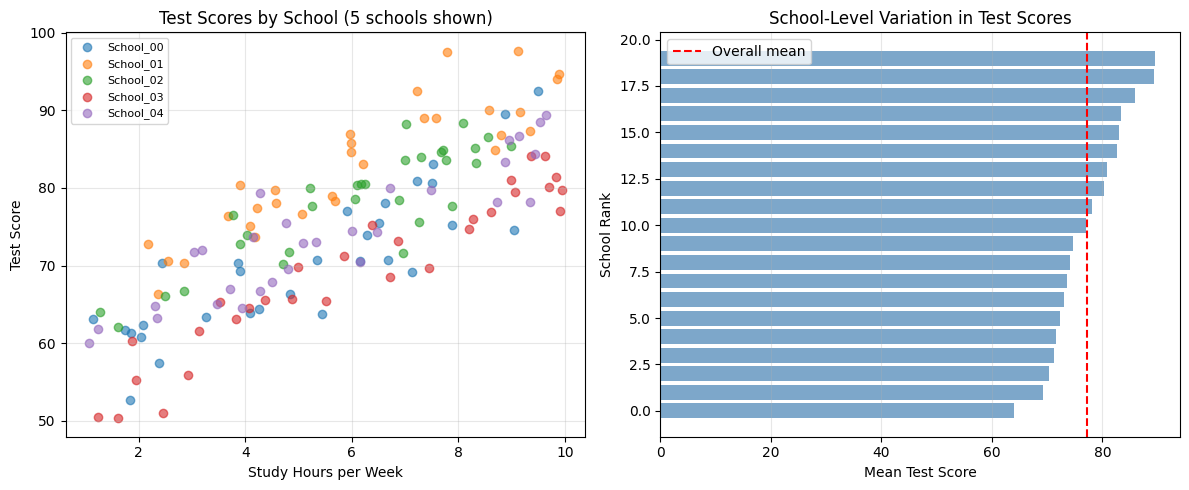

Overall mean score: 77.2
Between-school SD: 7.0
Within-school SD: 8.6


In [3]:
# Sample 5 schools for visualization
sample_schools = df['school'].unique()[:5]
df_sample = df[df['school'].isin(sample_schools)]

plt.figure(figsize=(12, 5))

# Subplot 1: Scores by school
plt.subplot(1, 2, 1)
for school in sample_schools:
    school_data = df_sample[df_sample['school'] == school]
    plt.scatter(school_data['study_hours'], school_data['score'], 
                alpha=0.6, label=school)
plt.xlabel('Study Hours per Week')
plt.ylabel('Test Score')
plt.title('Test Scores by School (5 schools shown)')
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

# Subplot 2: Distribution of school means
plt.subplot(1, 2, 2)
school_means = df.groupby('school')['score'].mean().sort_values()
plt.barh(range(len(school_means)), school_means.values, color='steelblue', alpha=0.7)
plt.xlabel('Mean Test Score')
plt.ylabel('School Rank')
plt.title('School-Level Variation in Test Scores')
plt.axvline(df['score'].mean(), color='r', linestyle='--', label='Overall mean')
plt.legend()
plt.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print(f"Overall mean score: {df['score'].mean():.1f}")
print(f"Between-school SD: {school_means.std():.1f}")
print(f"Within-school SD: {df.groupby('school')['score'].std().mean():.1f}")

**Observation:** Different schools have different baseline scores, even after accounting for study hours!

## 5. Comparison: Fixed Effects vs Random Effects

### Model 1: GLM (ignoring school structure)

In [4]:
# Fit GLM (ignoring schools)
X_glm = np.column_stack([
    np.ones(n),  # Intercept
    df['study_hours']  # Study hours
])
y = df['score'].values

result_glm = fit_glm(X=X_glm, y=y, family='gaussian')

print("GLM Results (ignoring schools):")
print(f"Intercept: {result_glm.coef_[0]:.2f}")
print(f"Study hours effect: {result_glm.coef_[1]:.2f}")

# Calculate residual variance (scale parameter for Gaussian GLM)
n_obs = len(y)
n_params = len(result_glm.coef_)
df_resid = n_obs - n_params
residual_variance = result_glm.deviance_ / df_resid
print(f"Residual variance: {residual_variance:.2f}")

# Calculate intraclass correlation (ICC)
# ICC = between-group variance / total variance
residuals_glm = y - result_glm.predict(X_glm)
total_var = np.var(residuals_glm)
school_means = df.groupby('school_id')['score'].transform('mean')
between_var = np.var(school_means - df['score'].mean())
icc = between_var / (between_var + total_var)
print(f"\nICC (intraclass correlation): {icc:.3f}")
print(f"-> {icc*100:.1f}% of variance is between schools!")

GLM Results (ignoring schools):
Intercept: 30.01
Study hours effect: 3.06
Residual variance: 54.98

ICC (intraclass correlation): 0.457
-> 45.7% of variance is between schools!


**Problem with GLM:**
- Ignores school structure
- Standard errors are too small (overconfident)
- Cannot predict for new schools
- High ICC suggests we need random effects!

## 6. Fit GAMM with Random Intercepts

### Model 2: GAMM with school-level random intercepts

In [5]:
# Prepare data for GAMM
X_gamm = X_glm.copy()  # Same fixed effects design matrix

# Specify random intercept for schools
re_school = RandomEffect(grouping='school', include_intercept=True)

# Fit GAMM with random intercepts
result_gamm = fit_gamm(
    y=y,
    X=X_gamm,
    random_effects=[re_school],
    groups_data={'school': df['school'].values},
    covariance='identity',  # Single variance parameter for school effects
    maxiter=100
)

print("GAMM Results (with random intercepts):")
print(f"\nFixed Effects:")
print(f"  Intercept: {result_gamm.beta_parametric[0]:.2f}")
print(f"  Study hours effect: {result_gamm.beta_parametric[1]:.2f}")
print(f"\nRandom Effects:")
print(f"  School SD: {np.sqrt(result_gamm.variance_components[0,0]):.2f}")
print(f"  Residual SD: {np.sqrt(result_gamm.residual_variance):.2f}")
print(f"\nModel converged: {result_gamm.converged}")
print(f"Iterations: {result_gamm.n_iterations}")

GAMM Results (with random intercepts):

Fixed Effects:
  Intercept: 60.45
  Study hours effect: 2.98

Random Effects:
  School SD: 6.50
  Residual SD: 3.84

Model converged: True
Iterations: 10


**Interpretation:**
- **Fixed effects:** Population-level effects (same for all schools)
- **Random effects SD:** Variation in school baselines
- **Residual SD:** Within-school variation (student-level noise)

## 7. Visualize Random Effects

### Caterpillar Plot

Shows estimated school effects with confidence intervals:

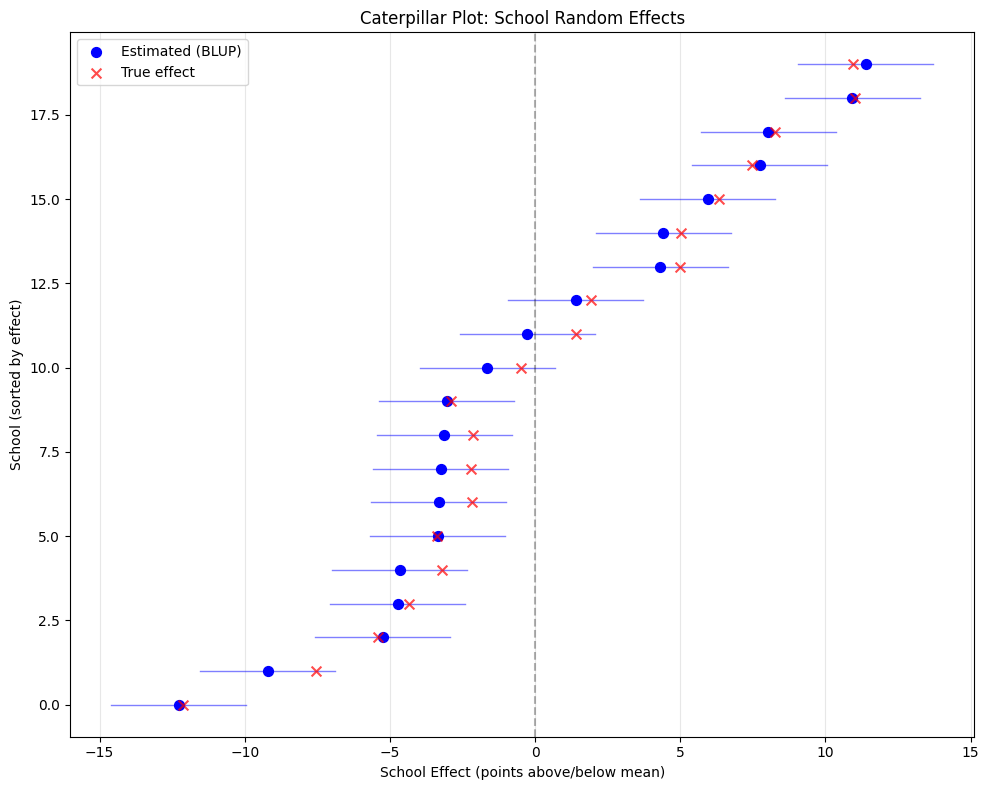

Correlation between true and estimated effects: 0.996


In [6]:
# Extract random effects (BLUPs - Best Linear Unbiased Predictors)
school_effects_dict = result_gamm.random_effects['school']

# The dict keys are school names (strings), not IDs (integers)
# Create a mapping from school names to their effects
school_name_to_id = df[['school', 'school_id']].drop_duplicates().set_index('school')['school_id'].to_dict()

# Extract effects in order of school_id
school_effects_estimated = np.array([
    school_effects_dict[f'School_{i:02d}'][0] if isinstance(school_effects_dict[f'School_{i:02d}'], np.ndarray)
    else school_effects_dict[f'School_{i:02d}']
    for i in range(n_schools)
])

# Sort by effect size
order = np.argsort(school_effects_estimated)
school_effects_sorted = school_effects_estimated[order]
true_effects_sorted = df.groupby('school_id')['true_school_effect'].first().values[order]

# Approximate standard errors (simplified)
se = np.sqrt(result_gamm.variance_components[0, 0] / n_students_per_school)
ci_lower = school_effects_sorted - 1.96 * se
ci_upper = school_effects_sorted + 1.96 * se

# Caterpillar plot
plt.figure(figsize=(10, 8))
y_pos = np.arange(n_schools)

# Plot confidence intervals
for i in y_pos:
    plt.plot([ci_lower[i], ci_upper[i]], [i, i], 'b-', alpha=0.5, lw=1)

# Plot estimates
plt.scatter(school_effects_sorted, y_pos, color='blue', s=50, 
            label='Estimated (BLUP)', zorder=3)

# Plot true effects
plt.scatter(true_effects_sorted, y_pos, color='red', marker='x', s=50,
            label='True effect', zorder=3, alpha=0.7)

plt.axvline(0, color='k', linestyle='--', alpha=0.3)
plt.xlabel('School Effect (points above/below mean)')
plt.ylabel('School (sorted by effect)')
plt.title('Caterpillar Plot: School Random Effects')
plt.legend()
plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Correlation between true and estimated
correlation = np.corrcoef(df.groupby('school_id')['true_school_effect'].first().values,
                          school_effects_estimated)[0, 1]
print(f"Correlation between true and estimated effects: {correlation:.3f}")

**Shrinkage:** Estimated effects are "pulled" toward zero (shrunk), especially for schools with fewer observations. This is a feature, not a bug—it provides more stable estimates!

## 8. Make Predictions

### Predict for existing school

In [7]:
# Predict for a student in School_00 with 5 hours of study
study_hours_new = 5
school_name = 'School_00'
school_idx = 0  # School_00

# Fixed effects prediction (population level)
X_new = np.array([[1, study_hours_new]])
pred_fixed = predict_from_gamm(result_gamm, X_new, include_random=False)

# School-specific prediction (fixed + random)
# For predict_from_gamm, we need to pass the school name, not the ID
# But the function expects group indices. Let's create a mapping
# We'll use school_id as the group index
groups_new = np.array([school_idx])
pred_school = predict_from_gamm(
    result_gamm, 
    X_new, 
    groups_new=groups_new,
    include_random=True
)

print(f"Predictions for student with {study_hours_new} study hours:")
print(f"\n1. Population-level (average school): {pred_fixed[0]:.1f} points")
print(f"2. School-specific ({school_name}): {pred_school[0]:.1f} points")

# Get the effect for this school
school_effect = school_effects_dict[school_name]
if isinstance(school_effect, np.ndarray):
    school_effect = school_effect[0]
    
print(f"   School effect: {school_effect:.1f}")
print(f"   Difference: {pred_school[0] - pred_fixed[0]:.1f} points")

Predictions for student with 5 study hours:

1. Population-level (average school): 75.4 points
2. School-specific (School_00): 70.1 points
   School effect: -5.3
   Difference: -5.3 points


## 9. Model Comparison

Compare GLM vs GAMM:

In [8]:
# Predictions
y_pred_glm = result_glm.predict(X_glm)

# For GAMM, include random effects for conditional predictions
groups_for_pred = df['school_id'].values
y_pred_gamm = predict_from_gamm(
    result_gamm, 
    X_gamm, 
    groups_new=groups_for_pred,
    include_random=True
)

# Calculate metrics
rmse_glm = np.sqrt(np.mean((y - y_pred_glm)**2))
rmse_gamm = np.sqrt(np.mean((y - y_pred_gamm)**2))

r2_glm = 1 - np.sum((y - y_pred_glm)**2) / np.sum((y - y.mean())**2)
r2_gamm = 1 - np.sum((y - y_pred_gamm)**2) / np.sum((y - y.mean())**2)

print("Model Comparison:")
print(f"\nGLM (ignoring schools):")
print(f"  RMSE: {rmse_glm:.2f}")
print(f"  R²: {r2_glm:.4f}")
print(f"\nGAMM (with random intercepts):")
print(f"  RMSE: {rmse_gamm:.2f}")
print(f"  R²: {r2_gamm:.4f}")
print(f"\nImprovement: {(r2_gamm - r2_glm) * 100:.1f}% increase in R²")
print(f"RMSE reduction: {rmse_glm - rmse_gamm:.2f} points")

Model Comparison:

GLM (ignoring schools):
  RMSE: 7.40
  R²: 0.5405

GAMM (with random intercepts):
  RMSE: 3.77
  R²: 0.8807

Improvement: 34.0% increase in R²
RMSE reduction: 3.63 points


## Key Concepts

- **Fixed effects**: Population-level parameters (same for all groups)
- **Random effects**: Group-level deviations (vary by group)
- **BLUPs**: Best Linear Unbiased Predictors (estimated random effects)
- **Shrinkage**: Random effects pulled toward zero (especially with few observations)
- **ICC**: Intraclass correlation (proportion of variance between groups)

## When to Use GAMM?

Use GAMM when:
- Data has hierarchical structure (nested/grouped)
- Observations within groups are correlated
- You want to generalize to new groups
- ICC > 0.05 (5% of variance between groups)

## Next Steps

- **Random slopes:** See `04_longitudinal/02_random_slopes.ipynb` for varying effects across groups
- **Nested random effects:** See `04_longitudinal/03_nested_random_effects.ipynb` for multi-level models
- **Binary outcomes:** See `06_case_studies/05_clinical_trial.ipynb` for logistic GAMM

## Resources

- [Aurora-GLM Documentation](https://github.com/Matcraft94/Aurora-GLM)
- [Gelman & Hill (2007) - Data Analysis Using Regression and Multilevel/Hierarchical Models](http://www.stat.columbia.edu/~gelman/arm/)
- [lme4 R package](https://cran.r-project.org/web/packages/lme4/index.html)